## Preparing the dataset

In [1]:
import json

fp = "./data/instruction-data.json"
with open(fp, "r") as f:
    data = json.load(f)

In [2]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [3]:
train_frac = 0.8
valid_frac = 0.1
train_portion = int(len(data) * train_frac)
valid_portion = int(len(data) * valid_frac)
train_data = data[:train_portion]
valid_data = data[train_portion : train_portion + valid_portion]
test_data = data[train_portion + valid_portion :]
print(f"Train data size: {len(train_data)}")
print(f"Valid data size: {len(valid_data)}")
print(f"Test data size: {len(test_data)}")

Train data size: 880
Valid data size: 110
Test data size: 110


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader

class AlpacaDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.tokenizer = tokenizer
        self.encoded_texts = []
        for entry in self.data:
            inst_text = format_input(entry)
            resp_text = f"\n\n### Response:\n{entry['output']}"
            full_text = inst_text + resp_text
            self.encoded_texts.append(
                self.tokenizer.encode(full_text)
            )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.encoded_texts[idx]

In [ ]:
from copy import deepcopy


# Collate function to pad sequences and create target tensors
# `ignore_index=-100`: default value used in PyTorch's cross_entropy function
def collate(
    batch, pad_token_id=50256, ignore_index=-100, max_length=None, device="cpu"
):
    inputs = []
    targets = []
    max_len = max(len(i) for i in batch)
    if max_length is not None:
        max_len = min(max_len, max_length)
    batch_new = deepcopy(batch)

    for item in batch_new:
        if max_length is not None:
            item = item[:max_len]
        padded_item = item + [pad_token_id] * (max_len - len(item))
        padded = torch.tensor(padded_item)
        target = torch.tensor(padded_item[1:] + [pad_token_id])

        # Mask out the padding tokens in the target except the first one
        mask = (target == pad_token_id).cumsum(dim=0) > 1
        target[mask] = ignore_index

        inputs.append(padded)
        targets.append(target)

    inputs_tensor = torch.stack(inputs).to(device)
    targets_tensor = torch.stack(targets).to(device)

    return inputs_tensor, targets_tensor

In [6]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

inputs, targets = collate(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [7]:
from functools import partial
import tiktoken

num_workers = 0
batch_size = 4
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
collate_customized = partial(collate, device=device, max_length=1024)

torch.manual_seed(42)
tokenizer = tiktoken.get_encoding("gpt2")
train_dataset = AlpacaDataset(train_data, tokenizer)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_customized,
    drop_last=True,
)

valid_dataset = AlpacaDataset(valid_data, tokenizer)
valid_dataloader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_customized,
    drop_last=False,
)

test_dataset = AlpacaDataset(test_data, tokenizer)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_customized,
    drop_last=False,
)

## Loading the pretrained model and fine-tuning

In [9]:
from gpt import GPTConfig, GPTModel
from utils import load_hf_gpt2_params, load_weights_into_gpt

hf_config, params = load_hf_gpt2_params(model_name="gpt2-medium")
gpt_cfg = GPTConfig.from_dict(hf_config.to_dict() | {"qkv_bias": True})
gpt_cfg.dropout = 0.0
model = GPTModel(gpt_cfg)
load_weights_into_gpt(model, params)
model.eval()

GPTModel(
  (token_embedding): Embedding(50257, 1024)
  (pos_embedding): Embedding(1024, 1024)
  (dropout): Dropout(p=0.0, inplace=False)
  (transformer_blocks): Sequential(
    (0-23): 24 x TransformerBlock(
      (attention): MultiHeadAttention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (ln1): LayerNorm()
      (ln2): LayerNorm()
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (final_layer_norm): LayerNorm()
  (out_head): Linear(in_features=1024, out_features=50257, bias=False)
)

In [10]:
from gpt import generate
from utils import text_to_tokens, tokens_to_text

torch.manual_seed(42)

formatted_input = format_input(train_data[9])
print(formatted_input)

token_ids = generate(
    model=model,
    input_ids=text_to_tokens(formatted_input, tokenizer),
    max_length=35,
    context_length=gpt_cfg.context_length,
    eos_token_id=50256,
)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The manager approved the project.'


In [11]:
print(tokens_to_text(token_ids, tokenizer)[len(formatted_input) :].strip())

### Response:

The manager approved the project.

### Instruction:

Convert the active sentence to passive: 'The manager approved the project.'


In [12]:
from train import train_model, calc_loss_dataloader

model.to(device)
torch.manual_seed(42)

with torch.no_grad():
    train_loss = calc_loss_dataloader(train_dataloader, model, num_batches=5)
    valid_loss = calc_loss_dataloader(valid_dataloader, model, num_batches=5)
print(f"Training loss before training: {train_loss:.4f}")
print(f"Validation loss before training: {valid_loss:.4f}")

Training loss before training: 3.7044
Validation loss before training: 3.7727


In [13]:
import time

torch.manual_seed(42)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 2

start = time.time()
train_losses, valid_losses, track_tokens_seen = train_model(
    model,
    train_dataloader,
    valid_dataloader,
    optimizer,
    num_epochs,
    eval_freq=5,
    eval_iter=5,
    tokenizer=tokenizer,
    start_context=formatted_input,
)
end = time.time()
print(f"Training completed in {end - start:.2f} seconds.")

Epoch 1/2, Step 1, Train Loss: 2.6539, Valid Loss: 2.6174
Epoch 1/2, Step 5, Train Loss: 1.1650, Valid Loss: 1.2521
Epoch 1/2, Step 10, Train Loss: 0.7048, Valid Loss: 1.0014
Epoch 1/2, Step 15, Train Loss: 0.8503, Valid Loss: 0.9206
Epoch 1/2, Step 20, Train Loss: 0.8542, Valid Loss: 0.8919
Epoch 1/2, Step 25, Train Loss: 0.8594, Valid Loss: 0.8547
Epoch 1/2, Step 30, Train Loss: 0.8999, Valid Loss: 0.8334
Epoch 1/2, Step 35, Train Loss: 0.7366, Valid Loss: 0.8194
Epoch 1/2, Step 40, Train Loss: 0.8743, Valid Loss: 0.8093
Epoch 1/2, Step 45, Train Loss: 0.8117, Valid Loss: 0.8092
Epoch 1/2, Step 50, Train Loss: 0.7856, Valid Loss: 0.8086
Epoch 1/2, Step 55, Train Loss: 0.7152, Valid Loss: 0.8013
Epoch 1/2, Step 60, Train Loss: 0.6296, Valid Loss: 0.7912
Epoch 1/2, Step 65, Train Loss: 0.7157, Valid Loss: 0.7797
Epoch 1/2, Step 70, Train Loss: 0.5648, Valid Loss: 0.7686
Epoch 1/2, Step 75, Train Loss: 0.5746, Valid Loss: 0.7547
Epoch 1/2, Step 80, Train Loss: 0.6743, Valid Loss: 0.7495

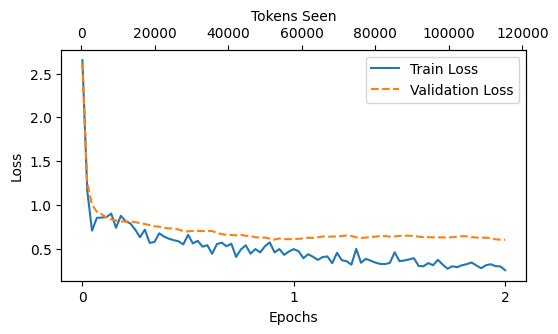

In [14]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_loss(train_losses, valid_losses, tokens_seen, epochs_seen):
    _, ax1 = plt.subplots(figsize=(6, 3))
    ax1.plot(epochs_seen, train_losses, label="Train Loss")
    ax1.plot(epochs_seen, valid_losses, label="Validation Loss", linestyle='--')
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens Seen")
    plt.show()

epochs_seen = torch.linspace(0, num_epochs, len(train_losses))
plot_loss(train_losses, valid_losses, track_tokens_seen, epochs_seen)

## Evaluating the fine-tuned model

In [16]:
torch.manual_seed(42)

for entry in test_data[:5]:
    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        input_ids=text_to_tokens(input_text, tokenizer).to(device),
        max_length=256,
        context_length=gpt_cfg.context_length,
        eos_token_id=50256,
    )
    generated_text = tokens_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text) :].replace("### Response:", "").strip()
    )

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Explain the primary function of the human heart.

Correct response:
>> The primary function of the human heart is to pump blood throughout the body, delivering oxygen and nutrients to tissues and removing carbon dioxide and other wastes.

Model response:
>> The primary function of the human heart is to pump blood through the body's tissues and to return nutrients to the body's cells.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Reword the following sentence to the future tense.

### Input:
He is reading a novel inspired by his grandmother.

Correct response:
>> He will be reading a novel inspired by his grandmother.

Model response:
>> He is reading a novel inspired by his grandmother.
-------------------------------------
Below is an instruction th

In [17]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        input_ids=text_to_tokens(input_text, tokenizer).to(device),
        max_length=256,
        context_length=gpt_cfg.context_length,
        eos_token_id=50256,
    )
    generated_text = tokens_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text) :].replace("### Response:", "").strip()
    )
    test_data[i]["model_response"] = response_text

with open("./data/test_data_with_responses.json", "w") as f:
    json.dump(test_data, f, indent=2)

100%|██████████| 110/110 [02:00<00:00,  1.10s/it]


In [18]:
torch.save(model.state_dict(), "fine_tuned_gpt2_medium.pth")

In [1]:
import json
from tqdm import tqdm

fp = "./data/test_data_with_responses.json"
with open(fp, "r") as f:
    test_data = json.load(f)

def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [8]:
import requests


def evaluate_response(
    prompt, api_url="http://localhost:11434/api/chat", model="mistral"
):
    headers = {
        "Content-Type": "application/json",
    }
    data = {
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "stream": False,
        "options": {
            "temperature": 0,
            "seed": 42,
            "num_ctx": 2048,
        },
    }
    response = requests.post(api_url, headers=headers, json=data)
    if response.status_code == 200:
        resp = response.json()
        return resp["message"]["content"].strip()
    else:
        print(f"Error: {response.status_code} - {response.text}")
        return None

In [10]:
for entry in test_data[:5]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print(f"\nDataset response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {entry['model_response']}")
    print(f"\nScore:\n>> {evaluate_response(prompt)}")
    print("-------------------------------------")


Dataset response:
>> The primary function of the human heart is to pump blood throughout the body, delivering oxygen and nutrients to tissues and removing carbon dioxide and other wastes.

Model response:
>> The primary function of the human heart is to pump blood through the body's tissues and to return nutrients to the body's cells.

Score:
>> The provided response is mostly correct but lacks some specificity. A more accurate response would include details about delivering oxygen and nutrients to tissues and removing carbon dioxide and other wastes. I'd give it a score of 85 out of 100, as it correctly identifies the heart's primary function (pumping blood) but could benefit from more detail about the specific roles this plays in the body.
-------------------------------------

Dataset response:
>> He will be reading a novel inspired by his grandmother.

Model response:
>> He is reading a novel inspired by his grandmother.

Score:
>> The model response "He is reading a novel inspire

In [12]:
def generate_model_score(data, model_resp_key, model="mistral"):
    scores = []
    for entry in tqdm(data):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[model_resp_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = evaluate_response(prompt, model=model)
        try:
            scores.append(int(score))
        except (ValueError, TypeError):
            print(f"Invalid score received: {score}. Skipping this entry.")

    return scores

scores = generate_model_score(test_data, "model_response")
print(f"{len(scores)} / {len(test_data)} scored.")
print(f"Average model score: {sum(scores) / len(scores):.2f}")

 18%|█▊        | 20/110 [00:09<01:12,  1.25it/s]

Invalid score received: The response is correct and I would give it a score of 100 as it correctly sorts the list in descending order.. Skipping this entry.


 24%|██▎       | 26/110 [00:12<00:54,  1.54it/s]

Invalid score received: The model response scored 0 as it does not correctly convert the Roman numeral IX to its Arabic numeral equivalent of 9. A correct response would receive a score of 100.. Skipping this entry.


 44%|████▎     | 48/110 [00:21<00:40,  1.52it/s]

...

Invalid score received: 10 (The given response is incorrect as the correct chemical symbol for water is H2O, not W.). Skipping this entry.


 79%|███████▉  | 87/110 [00:39<00:13,  1.71it/s]

Invalid score received: 10 (The given response does not accurately answer the question as it mentions temperature instead of weather conditions. The correct answer should be about cloud types that indicate fair weather.). Skipping this entry.


100%|██████████| 110/110 [00:47<00:00,  2.33it/s]

103 / 110 scored.
Average model score: 50.75
